# 2 BODY PROBLEM

Firstly, we analize closed orbits, $0 \leq e<1$, that can be easily demonstrated to be elliptical and are given from the following analytical equation:

$$ 
\begin{equation}
    r=\frac{l^2}{(ecos(\theta-\theta_0)+1)GM}
\end{equation}
$$

Where $M=m_1+m_2$ is the sum of the masses of the 2 bodies and $l$ is the angular momentum per unit mass, that can be written as

$$
\begin{equation}
    l=\sqrt{aGM(1+e^2)}
\end{equation}
$$

The total energy per unit mass of the system is 

$$
\begin{equation}
    E=-\frac{GM}{2a}
\end{equation}
$$





To tackle the 2 body problem, we put ourselves in the reference frame of the center of mass.

\begin{equation}
    \vec{r_1}=\frac{m_2}{M}\vec{r}
\end{equation}

\begin{equation}
    \vec{r_2}=-\frac{m_1}{M}\vec{r}
\end{equation}

At this point, we choose to use polar coordinates and we recover equations for the velocity components from the angular momentum definition and the conservation of energy.

\begin{equation}
    v_\theta=\frac{l}{r}
\end{equation}

\begin{equation}
    v_r=\sqrt{-v_\theta^2+\frac{2GM}{r}-\frac{GM}{a}}
\end{equation}


Given a closed orbit, we can identify pericenter and apocenter.

\begin{equation}
    r_p=a(1-e)
\end{equation}

\begin{equation}
    r_a=a(1+e)
\end{equation}

To solve the problem numerically, through the code that we were given, we need to adimensionalize the equations at play, to set $G=1$ in internal units. We choose the units for time and mass and consequentially we derive the units for length.

\begin{equation}
   \frac {M \ [g] \cdot G \ [cm^3 \cdot g^{-1} \cdot s^{-2}]}{v^2 \ [cm \cdot s^{-1}] ^2 \cdot r \ [cm]} = \frac {M \ [IU] \cdot G \ [IU]}{v^2 \ [IU] \cdot r \ [IU]} 
\end{equation}


\begin{equation}
    M \ [g] = 2   \cdot  10^{33} \ M \ [IU]
\end{equation}

\begin{equation}
    t \ [s] =  10^{6} \ t \ [IU]
\end{equation}

\begin{equation}
    r \ [cm] =  5.11  \cdot  10^{12} \ r \ [IU]
\end{equation}



To tackle the code, we need to impose some parameters and derive the initial conditions for positions and velocities of both bodies. \
Firstly, we pick $m_1$, $m_2$, $e$ and $a$, in order to identify a specific orbit. \
We choose the pericenter of the orbit as the starting point for our simulation, so we proceed to derive the positions and velocities of the two bodies.
For practical purposes, we pick the initial phase $\theta_0=0$, which means that the pericenter lays on our $x$ axis. \
Knowing the distance of the two bodies at the pericenter $r_p=a(1-e)$ in the reference frame of the center of mass, we can revert their coordinates in our reference frame and convert them from polar to cartesian. While, from the afore stated equations, we can derive the velocity components. \
Given our choices, the initial $y$ coordinate of both bodies is null and so is the initial $x$ component of both bodies velocity, since at pericenter, there's no radial velocity.

First off, we analyse the Sun-Earth orbit with the following parameters:
$$e=0.0167$$
$$a=1.5 \cdot 10^{13} \ cm$$
$$m_1= 10^{-6} M_\odot$$
$$m_2= 1 \  M_\odot$$

## LIBRARIES

In [282]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import pandas as pd

## CONVERSIONS

In [283]:
def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

## FUNCTIONS

In [284]:
def write_ic_file(filename, ic, t0=0.0):
    x1, y1, z1 = ic["r1"]
    vx1, vy1, vz1 = ic["v1"]

    x2, y2, z2 = ic["r2"]
    vx2, vy2, vz2 = ic["v2"]

    with open(filename, "w") as f:
        f.write("2\n")
        f.write(f"{t0:.16e}\n")
        f.write(
            f"{ic['m1']:.16e} {x1:.16e} {y1:.16e} {z1:.16e} "
            f"{vx1:.16e} {vy1:.16e} {vz1:.16e}\n"
        )
        f.write(
            f"{ic['m2']:.16e} {x2:.16e} {y2:.16e} {z2:.16e} "
            f"{vx2:.16e} {vy2:.16e} {vz2:.16e}\n"
        )

In [285]:
def rows(data):
    time_rows = data[data.index % 4 -1 == 0]
    times = (time_rows['m'])
    
    m1_rows = data[data.index % 4 -2 == 0]
    m2_rows = data[data.index % 4 -3 == 0]
    return times, m1_rows, m2_rows

In [286]:
def analytical_traj(theta,theta_0,l,e,M, G=1):
    return l**2/((e*np.cos(theta-theta_0)+1)*M*G)

In [287]:
def analytical(theta,theta0,a,e,m1,m2):
    M=m1+m2
    l = np.sqrt(a*M*(1+e**2)) #angular momentum per u. mass in internal units
    analytical_r = analytical_traj(theta,theta0,l,e,M)
    
    analytical_r1 = -m2/M * analytical_r
    analytical_r2 = m1/M * analytical_r
    
    analytical_x1 = analytical_r1 * np.cos(theta)
    analytical_y1 = analytical_r1 * np.sin(theta)
    analytical_x2 = analytical_r2 * np.cos(theta)
    analytical_y2 = analytical_r2 * np.sin(theta)
    return analytical_x1, analytical_y1, analytical_x2, analytical_y2

# ELLIPTICAL

In [288]:
def cm_to_u(r_cm, L_unit_cm=5.11e12):
    """
    da cm a unità interne.
    """
    return r_cm / L_unit_cm


def u_to_cm(r_u, L_unit_cm=5.11e12):
    """
    da unità interne a cm.
    """
    return r_u * L_unit_cm


# =========================================================
# Condizioni iniziali cartesiane al pericentro
# =========================================================

def two_body_ic_pericenter(m1, m2, a, e, G=1.0):
    if not (0.0 <= e < 1.0):
        raise ValueError("Per orbita bound serve 0 <= e < 1.")

    M = m1 + m2

    # Distanza al pericentro
    r_p = a * (1.0 - e)

    # Velocità al pericentro
    v_p = np.sqrt(G * M * (1.0 + e) / (a * (1.0 - e)))

    # Vettori relativi cartesiani
    r_rel = np.array([r_p, 0.0, 0.0], dtype=float)
    v_rel = np.array([0.0, v_p, 0.0], dtype=float)

    # Passaggio al frame del centro di massa
    r1 = -(m2 / M) * r_rel
    r2 = +(m1 / M) * r_rel

    v1 = -(m2 / M) * v_rel
    v2 = +(m1 / M) * v_rel

    # Check utili
    eps = 0.5 * np.dot(v_rel, v_rel) - G * M / np.linalg.norm(r_rel)
    eps_theory = -G * M / (2.0 * a)
    T = 2.0 * np.pi * np.sqrt(a**3 / (G * M))

    return {
        "m1": m1,
        "m2": m2,
        "M": M,
        "a": a,
        "e": e,
        "r_p": r_p,
        "v_p": v_p,
        "r1": r1,
        "r2": r2,
        "v1": v1,
        "v2": v2,
        "r_rel": r_rel,
        "v_rel": v_rel,
        "eps": eps,
        "eps_theory": eps_theory,
        "T": T,
    }



def print_ic(ic):
    print("=== PARAMETERS ===")
    print(f"m1 = {ic['m1']}")
    print(f"m2 = {ic['m2']}")
    print(f"M  = {ic['M']}")
    print(f"a  = {ic['a']}")
    print(f"e  = {ic['e']}")
    print()

    print("=== RELATIVE MOTION ===")
    print(f"r_rel = {ic['r_rel']}")
    print(f"v_rel = {ic['v_rel']}")
    print(f"r_p   = {ic['r_p']}")
    print(f"v_p   = {ic['v_p']}")
    print()

    print("=== BODY 1 ===")
    print(f"r1 = {ic['r1']}")
    print(f"v1 = {ic['v1']}")
    print()

    print("=== BODY 2 ===")
    print(f"r2 = {ic['r2']}")
    print(f"v2 = {ic['v2']}")
    print()
    '''
    print("=== CHECK ENERGIA ===")
    print(f"eps numerica = {ic['eps']}")
    print(f"eps teorica  = {ic['eps_theory']}")
    print(f"T            = {ic['T']}")
    '''

## ELLIPSE: PARAMETERS

### Sun and Earth

In [289]:
m1_DM = 1.0e-6
m2_DM = 1.0
e_DM = 0.0167


a_cm = 1.5e13
a = cm_to_u(a_cm)  

G = 1.0
t0 = 0.0


ic = two_body_ic_pericenter(m1=m1_DM, m2=m2_DM, a=a, e=e_DM, G=G)


print_ic(ic)


outname = "IC_elli_DM.txt"
write_ic_file(outname, ic, t0=t0)

print()
print(f"File '{outname}' scritto correttamente.")

=== PARAMETERS ===
m1 = 1e-06
m2 = 1.0
M  = 1.000001
a  = 2.935420743639922
e  = 0.0167

=== RELATIVE MOTION ===
r_rel = [2.88639922 0.         0.        ]
v_rel = [0.         0.59349687 0.        ]
r_p   = 2.886399217221135
v_p   = 0.5934968658750599

=== BODY 1 ===
r1 = [-2.88639633 -0.         -0.        ]
v1 = [-0.         -0.59349627 -0.        ]

=== BODY 2 ===
r2 = [2.88639633e-06 0.00000000e+00 0.00000000e+00]
v2 = [0.00000000e+00 5.93496272e-07 0.00000000e+00]


File 'IC_elli_DM.txt' scritto correttamente.


### Same Mass

In [290]:
m1_SM = 1.0
m2_SM = 1.0
e_SM = 0.5


a_cm = 1.5e13
a = cm_to_u(a_cm)  

G = 1.0
t0 = 0.0


ic = two_body_ic_pericenter(m1=m1_SM, m2=m2_SM, a=a, e=e_SM, G=G)


print_ic(ic)


outname = "IC_elli_SM.txt"
write_ic_file(outname, ic, t0=t0)

print()
print(f"File '{outname}' scritto correttamente.")

=== PARAMETERS ===
m1 = 1.0
m2 = 1.0
M  = 2.0
a  = 2.935420743639922
e  = 0.5

=== RELATIVE MOTION ===
r_rel = [1.46771037 0.         0.        ]
v_rel = [0.         1.42968528 0.        ]
r_p   = 1.467710371819961
v_p   = 1.4296852800529214

=== BODY 1 ===
r1 = [-0.73385519 -0.         -0.        ]
v1 = [-0.         -0.71484264 -0.        ]

=== BODY 2 ===
r2 = [0.73385519 0.         0.        ]
v2 = [0.         0.71484264 0.        ]


File 'IC_elli_SM.txt' scritto correttamente.


## Data Analysis

In [291]:
theta = np.linspace(0,np.pi*2*5,1000)
x1_DM,y1_DM,x2_DM,y2_DM=analytical(theta,0,a,e_DM,m1_DM,m2_DM)
x1_SM,y1_SM,x2_SM,y2_SM=analytical(theta,0,a,e_SM,m1_SM,m2_SM)

In [292]:
data_DM = pd.read_csv('2b_output_elli_DM.txt', sep=' ', header=None, names=range(7))
data_DM.columns = ['m','x','y','z','vx','vy','vz']

data_SM = pd.read_csv('2b_output_elli_SM.txt', sep=' ', header=None, names=range(7))
data_SM.columns = ['m','x','y','z','vx','vy','vz']

In [293]:
#print(data_DM, data_SM)

In [294]:
times_DM, M1_DM, M2_DM = rows(data_DM)
times_SM, M1_SM, M2_SM = rows(data_SM)

Text(0.5, 1.0, 'e=5.0, $m_1$=$m_2$=1.0$M_\\odot$')

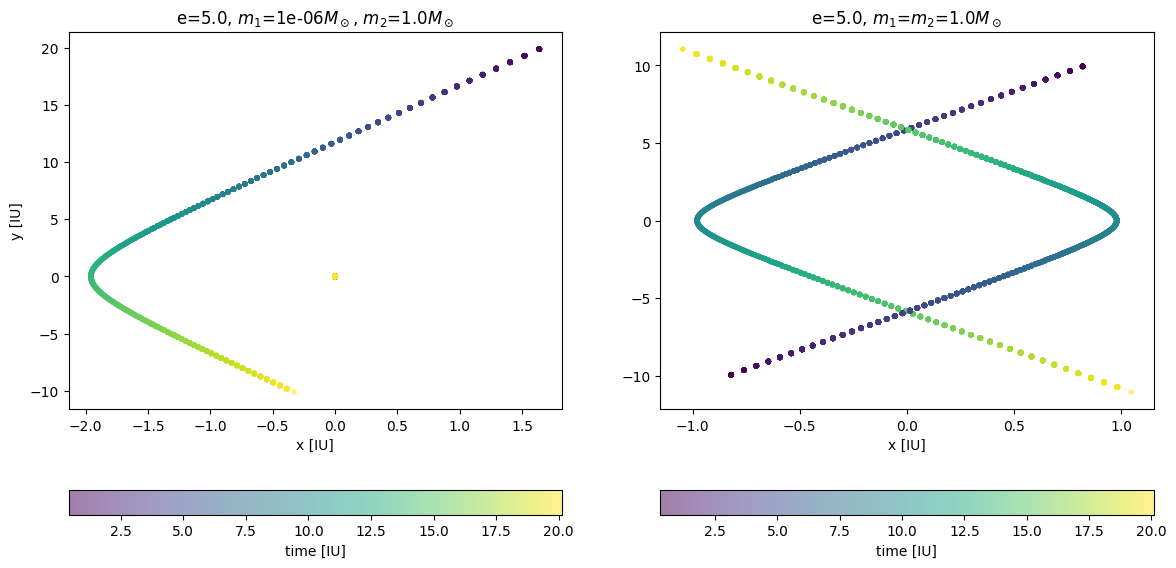

In [327]:
color_DM = times_DM
color_SM = times_SM

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(M1_DM['x'],M1_DM['y'], c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(M2_DM['x'],M2_DM['y'], c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(M1_SM['x'],M1_SM['y'], c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(M2_SM['x'],M2_SM['y'], c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [IU]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [IU]')
axs[0].set_xlabel('x [IU]')
axs[0].set_ylabel('y [IU]')
axs[1].set_xlabel('x [IU]')

#axs[0].plot(x1_DM,y1_DM, lw=0.5, c='crimson')
#axs[0].plot(x2_DM,y2_DM, lw=0.5, c='crimson')
#axs[1].plot(x1_SM,y1_SM, lw=0.5, c='crimson')
#axs[1].plot(x2_SM,y2_SM, lw=0.5, c='crimson')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

Text(0.5, 1.0, 'e=0.5, $m_1$=$m_2$=1.0$M_\\odot$')

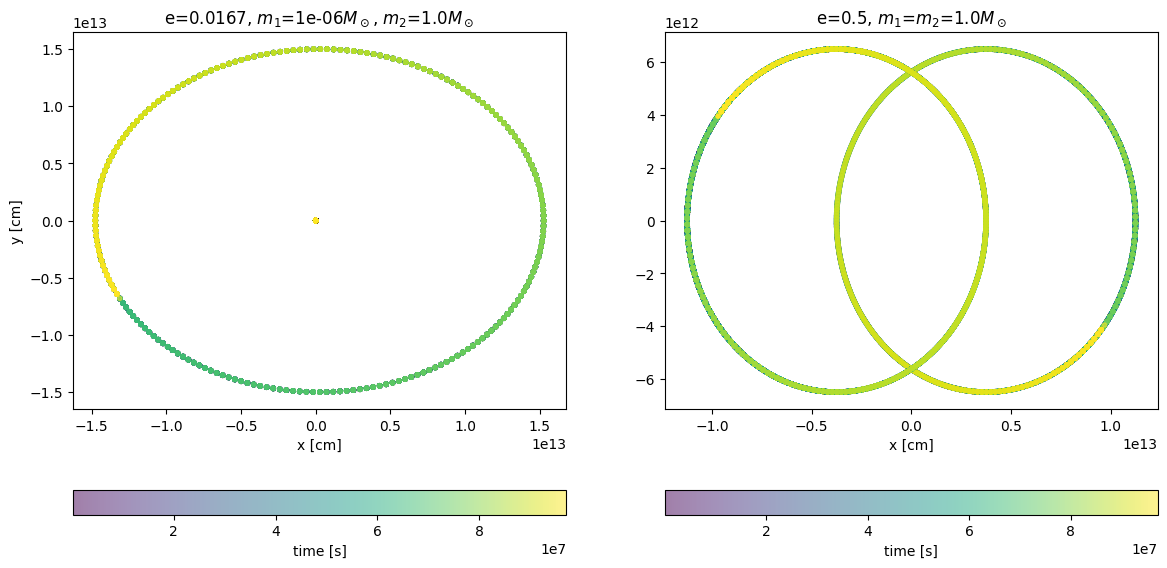

In [296]:
color_DM = t_int_to_s(times_DM)
color_SM = t_int_to_s(times_SM)

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(r_int_to_cm(M1_DM['x']),r_int_to_cm(M1_DM['y']), c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(r_int_to_cm(M2_DM['x']),r_int_to_cm(M2_DM['y']), c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(r_int_to_cm(M1_SM['x']),r_int_to_cm(M1_SM['y']), c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(r_int_to_cm(M2_SM['x']),r_int_to_cm(M2_SM['y']), c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [s]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [s]')
axs[0].set_xlabel('x [cm]')
axs[0].set_ylabel('y [cm]')
axs[1].set_xlabel('x [cm]')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

In [297]:
def r(x1, y1, x2, y2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

In [298]:
x1 = np.array(M1_DM['x'])
x2 = np.array(M2_DM['x'])
y1 = np.array(M1_DM['y'])
y2 = np.array(M2_DM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_DM.iloc[0]['m'] + M2_DM.iloc[0]['m']
mu = (M1_DM.iloc[0]['m'] * M2_DM.iloc[0]['m'])/M

rad_DM = r(x1, y1, x2, y2)
vrad_DM = r(np.array(M1_DM['vx']),np.array(M1_DM['vy']),np.array(M2_DM['vx']),np.array(M2_DM['vy']))

EG_DM = -M*mu/rad_DM
EK_DM = 0.5*mu*vrad_DM**2

print("DIFFERENT MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_DM =',e, "to be compared with", e_DM)

a_s = (aper+aapo)/2
print('a_DM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_DM+m2_DM)/(2*a)
print('E_tot,DM =',Etot, "to be compared with", E)

print(" ")

x1 = np.array(M1_SM['x'])
x2 = np.array(M2_SM['x'])
y1 = np.array(M1_SM['y'])
y2 = np.array(M2_SM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_SM.iloc[0]['m'] + M2_SM.iloc[0]['m']
mu = (M1_SM.iloc[0]['m'] * M2_SM.iloc[0]['m'])/M

print("SAME MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_SM =',e, "to be compared with", e_SM)

a_s = (aper+aapo)/2
print('a_SM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_SM+m2_SM)/(2*a)
print('E_tot,SM =',Etot, "to be compared with", E)

rad_SM = r(x1, y1, x2, y2)
vrad_SM = r(np.array(M1_SM['vx']),np.array(M1_SM['vy']),np.array(M2_SM['vx']),np.array(M2_SM['vy']))

EG_SM = -M*mu/rad_SM
EK_SM = 0.5*mu*vrad_SM**2

DIFFERENT MASS
e_DM = 0.016699935344029714 to be compared with 0.0167
a_DM = 2.935420550138617 to be compared with 2.935420743639922
E_tot,DM = -0.17033351489495732 to be compared with -0.17033350366666664
 
SAME MASS
e_SM = 0.499999415432182 to be compared with 0.5
a_SM = 2.935422495608352 to be compared with 2.935420743639922
E_tot,SM = -0.3406664633442331 to be compared with -0.3406666666666667


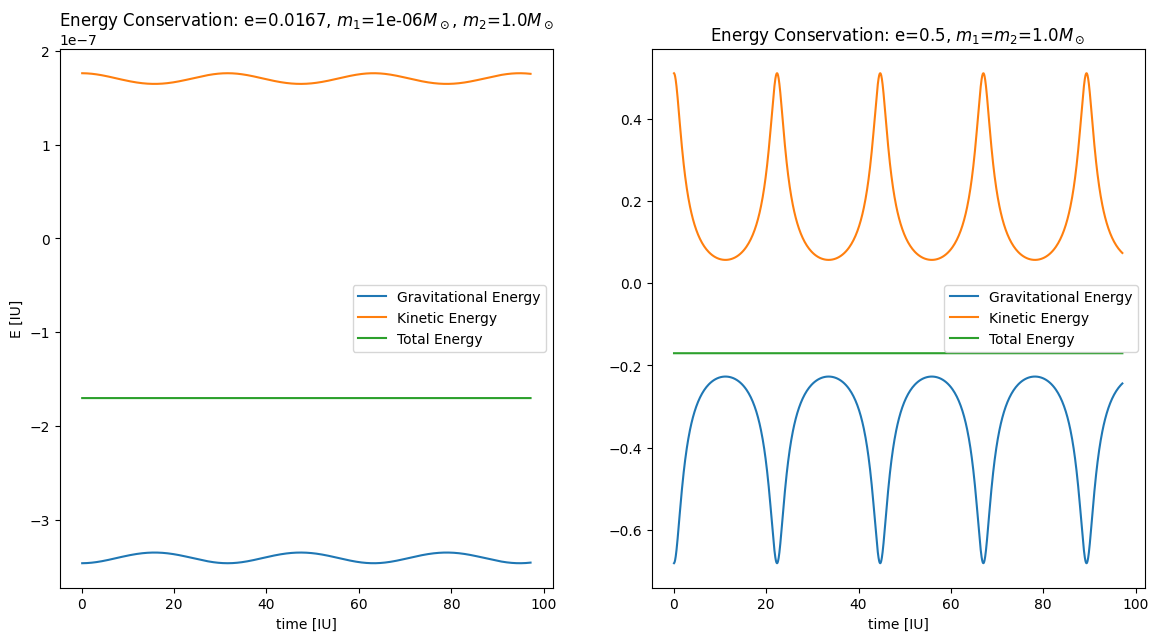

In [299]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,EG_DM,label='Gravitational Energy')
axs[0].plot(times_DM,EK_DM,label='Kinetic Energy')
axs[0].plot(times_DM,EK_DM+EG_DM,label='Total Energy')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('E [IU]')
axs[0].set_title('Energy Conservation:'+' e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[0].legend()

axs[1].plot(times_SM,EG_SM,label='Gravitational Energy')
axs[1].plot(times_SM,EK_SM,label='Kinetic Energy')
axs[1].plot(times_SM,EK_SM+EG_SM,label='Total Energy')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Energy Conservation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()

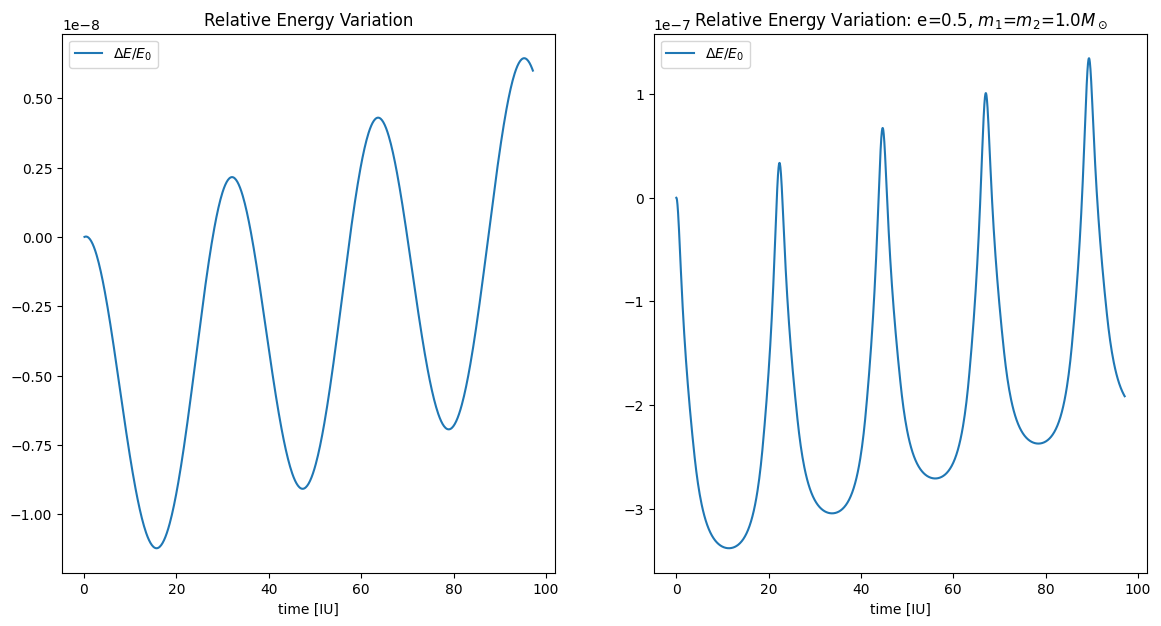

In [300]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,(EK_DM+EG_DM-(EK_DM[0]+EG_DM[0]))/(EK_DM[0]+EG_DM[0]),label=r'$\Delta E/E_0$')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('')
axs[0].set_title('Relative Energy Variation')
axs[0].legend()

axs[1].plot(times_SM,(EK_SM+EG_SM-(EK_SM[0]+EG_SM[0]))/(EK_SM[0]+EG_SM[0]),label=r'$\Delta E/E_0$')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Relative Energy Variation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()

# PARABOLIC AND HYPERBOLIC

In [301]:
def two_body_ic_hyperbolic_from_rp(
    m1,
    m2,
    rp,
    e,
    start_factor,
    omega_deg=0.0,
    G=1.0
):
    """
    Parametri:
    m1, m2 : masse
    rp     : pericentro del moto relativo
    e      : eccentricità (>1)
    start_factor : distanza iniziale r0 = start_factor * rp
    omega_deg    : rotazione dell'orbita nel piano xy
    G            : costante gravitazionale in unità interne
    """

    M = m1 + m2
    omega = np.radians(omega_deg)

    # semilato retto
    p = rp * (1.0 + e)

    # distanza iniziale scelta
    r0 = start_factor * rp

    # angolo vero iniziale sul ramo entrante
    cos_phi0 = (p / r0 - 1.0) / e
    if cos_phi0 < -1.0 or cos_phi0 > 1.0:
        raise ValueError(
            "Questa scelta di r0 non è compatibile con l'orbita. "
            "Prova ad aumentare start_factor."
        )

    phi0 = -np.arccos(cos_phi0)   # ramo incoming
    theta0 = phi0 + omega

    # posizione relativa
    r_rel = np.array([
        r0 * np.cos(theta0),
        r0 * np.sin(theta0),
        0.0
    ], dtype=float)

    # velocità relativa in coordinate polari
    fac = np.sqrt(G * M / p)
    vr0 = fac * e * np.sin(phi0)
    vt0 = fac * (1.0 + e * np.cos(phi0))

    # conversione in cartesiane
    v_rel = np.array([
        vr0 * np.cos(theta0) - vt0 * np.sin(theta0),
        vr0 * np.sin(theta0) + vt0 * np.cos(theta0),
        0.0
    ], dtype=float)

    # passaggio al frame del centro di massa
    r1 = -(m2 / M) * r_rel
    r2 = +(m1 / M) * r_rel
    v1 = -(m2 / M) * v_rel
    v2 = +(m1 / M) * v_rel

    # diagnostica orbitale
    h = np.linalg.norm(np.cross(r_rel, v_rel))               # specific angular momentum
    eps = 0.5 * np.dot(v_rel, v_rel) - G * M / np.linalg.norm(r_rel)  # specific energy
    a = -G * M / (2.0 * eps)                                 # negativo per iperbole
    vinf = np.sqrt(2.0 * eps)
    b = h / vinf
    rp_check = h**2 / (G * M * (1.0 + e))

    return {
        "m1": m1,
        "m2": m2,
        "M": M,
        "e": e,
        "rp": rp,
        "p": p,
        "r0": r0,
        "phi0": phi0,
        "theta0": theta0,
        "r_rel": r_rel,
        "v_rel": v_rel,
        "vr0": vr0,
        "vt0": vt0,
        "r1": r1,
        "r2": r2,
        "v1": v1,
        "v2": v2,
        "h": h,
        "eps": eps,
        "a": a,
        "vinf": vinf,
        "b": b,
        "rp_check": rp_check
    }

In [302]:
def print_ic_summary(ic):
    print("===== PARAMETERS =====")
    print(f"m1        = {ic['m1']}")
    print(f"m2        = {ic['m2']}")
    print(f"M         = {ic['M']}")
    print(f"e         = {ic['e']}")
    print(f"rp        = {ic['rp']}")
    print(f"p         = {ic['p']}")
    print(f"r0        = {ic['r0']}")
    print()
    print("===== ANGLES =====")
    print(f"phi0 [rad]    = {ic['phi0']}")
    print(f"theta0 [rad] = {ic['theta0']}")
    print()
    print("===== RELATIVE MOTION =====")
    print(f"r_rel = {ic['r_rel']}")
    print(f"v_rel = {ic['v_rel']}")
    print(f"vr0   = {ic['vr0']}")
    print(f"vt0   = {ic['vt0']}")
    print()
    print("===== DYNAMICAL CHECKS =====")
    print(f"h         = {ic['h']}")
    print(f"eps       = {ic['eps']}   (deve essere > 0)")
    print(f"a         = {ic['a']}     (deve essere < 0)")
    print(f"vinf      = {ic['vinf']}")
    print(f"b         = {ic['b']}")
    print(f"rp_check  = {ic['rp_check']}")
    print()
    print("===== BODY 1 =====")
    print(f"r1 = {ic['r1']}")
    print(f"v1 = {ic['v1']}")
    print()
    print("===== BODY 2 =====")
    print(f"r2 = {ic['r2']}")
    print(f"v2 = {ic['v2']}")

## PARABOLA: PARAMETERS

### Different Masses

In [303]:
m1_DM = 1.0e-6
m2_DM = 1.0

e_DM = 1.0

rp_cm = 1.0e13
rp = cm_to_u(rp_cm)

start_factor = 10.5

# orientazione nel piano
omega_deg = 0.0

ic = two_body_ic_hyperbolic_from_rp(
    m1=m1_DM,
    m2=m2_DM,
    rp=rp,
    e=e_DM,
    start_factor=start_factor,
    omega_deg=omega_deg,
    G=1.0
)

print_ic_summary(ic)

write_ic_file("IC_para_DM.txt", ic, t0=0.0)
print("\nFile IC_para.txt scritto correttamente.")

===== PARAMETERS =====
m1        = 1e-06
m2        = 1.0
M         = 1.000001
e         = 1.0
rp        = 1.9569471624266144
p         = 3.9138943248532287
r0        = 20.54794520547945

===== ANGLES =====
phi0 [rad]    = -2.5141368806666025
theta0 [rad] = -2.5141368806666025

===== RELATIVE MOTION =====
r_rel = [-16.63405088 -12.06343249   0.        ]
v_rel = [0.29675508 0.09628006 0.        ]
vr0   = -0.2967550844163991
vt0   = 0.09628006304361532

===== DYNAMICAL CHECKS =====
h         = 1.9783574598003146
eps       = 2.0816681711721685e-17   (deve essere > 0)
a         = -2.4019222031840656e+16     (deve essere < 0)
vinf      = 6.452392069879462e-09
b         = 306608376.9204795
rp_check  = 1.9569471624266144

===== BODY 1 =====
r1 = [16.63403425 12.06342043 -0.        ]
v1 = [-0.29675479 -0.09627997 -0.        ]

===== BODY 2 =====
r2 = [-1.66340342e-05 -1.20634204e-05  0.00000000e+00]
v2 = [2.96754788e-07 9.62799668e-08 0.00000000e+00]

File IC_para.txt scritto correttamente.


### Same Mass

In [304]:
m1_SM = 1.0
m2_SM = 1.0

e_SM = 1.0

rp_cm = 1.0e13
rp = cm_to_u(rp_cm)

start_factor = 10.5

# orientazione nel piano
omega_deg = 0.0

ic = two_body_ic_hyperbolic_from_rp(
    m1=m1_SM,
    m2=m2_SM,
    rp=rp,
    e=e_SM,
    start_factor=start_factor,
    omega_deg=omega_deg,
    G=1.0
)

print_ic_summary(ic)

write_ic_file("IC_para_SM.txt", ic, t0=0.0)
print("\nFile IC_para.txt scritto correttamente.")

===== PARAMETERS =====
m1        = 1.0
m2        = 1.0
M         = 2.0
e         = 1.0
rp        = 1.9569471624266144
p         = 3.9138943248532287
r0        = 20.54794520547945

===== ANGLES =====
phi0 [rad]    = -2.5141368806666025
theta0 [rad] = -2.5141368806666025

===== RELATIVE MOTION =====
r_rel = [-16.63405088 -12.06343249   0.        ]
v_rel = [0.41967486 0.1361605  0.        ]
vr0   = -0.4196748552474691
vt0   = 0.13616050286218298

===== DYNAMICAL CHECKS =====
h         = 2.7978185519626644
eps       = 2.7755575615628914e-17   (deve essere > 0)
a         = -3.602879701896397e+16     (deve essere < 0)
vinf      = 7.450580596923828e-09
b         = 375516849.40067875
rp_check  = 1.956947162426615

===== BODY 1 =====
r1 = [ 8.31702544  6.03171625 -0.        ]
v1 = [-0.20983743 -0.06808025 -0.        ]

===== BODY 2 =====
r2 = [-8.31702544 -6.03171625  0.        ]
v2 = [0.20983743 0.06808025 0.        ]

File IC_para.txt scritto correttamente.


In [305]:
theta = np.linspace(0,np.pi*2*5,1000)
x1_DM,y1_DM,x2_DM,y2_DM=analytical(theta,0,a,e_DM,m1_DM,m2_DM)
x1_SM,y1_SM,x2_SM,y2_SM=analytical(theta,0,a,e_SM,m1_SM,m2_SM)

In [306]:
data_DM = pd.read_csv('2b_output_para_DM.txt', sep=' ', header=None, names=range(7))
data_DM.columns = ['m','x','y','z','vx','vy','vz']

data_SM = pd.read_csv('2b_output_para_SM.txt', sep=' ', header=None, names=range(7))
data_SM.columns = ['m','x','y','z','vx','vy','vz']

In [307]:
#print(data_DM, data_SM)

In [308]:
times_DM, M1_DM, M2_DM = rows(data_DM)
times_SM, M1_SM, M2_SM = rows(data_SM)

Text(0.5, 1.0, 'e=1.0, $m_1$=$m_2$=1.0$M_\\odot$')

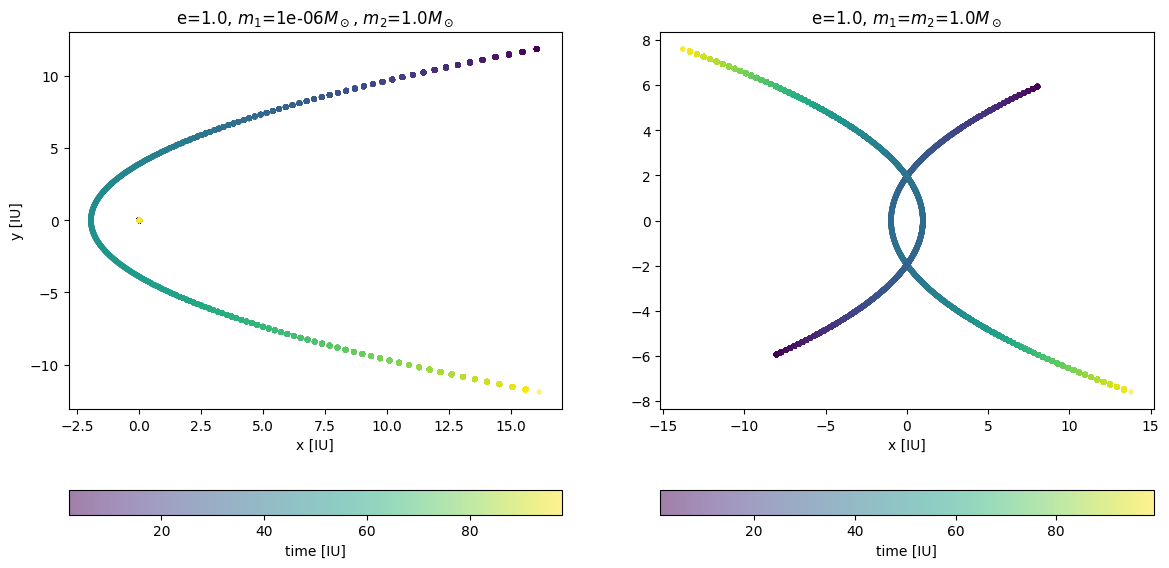

In [309]:
color_DM = times_DM
color_SM = times_SM

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(M1_DM['x'],M1_DM['y'], c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(M2_DM['x'],M2_DM['y'], c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(M1_SM['x'],M1_SM['y'], c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(M2_SM['x'],M2_SM['y'], c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [IU]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [IU]')
axs[0].set_xlabel('x [IU]')
axs[0].set_ylabel('y [IU]')
axs[1].set_xlabel('x [IU]')

#axs[0].plot(x1_DM,y1_DM, lw=0.5, c='crimson')
#axs[0].plot(x2_DM,y2_DM, lw=0.5, c='crimson')
#axs[1].plot(x1_SM,y1_SM, lw=0.5, c='crimson')
#axs[1].plot(x2_SM,y2_SM, lw=0.5, c='crimson')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

Text(0.5, 1.0, 'e=1.0, $m_1$=$m_2$=1.0$M_\\odot$')

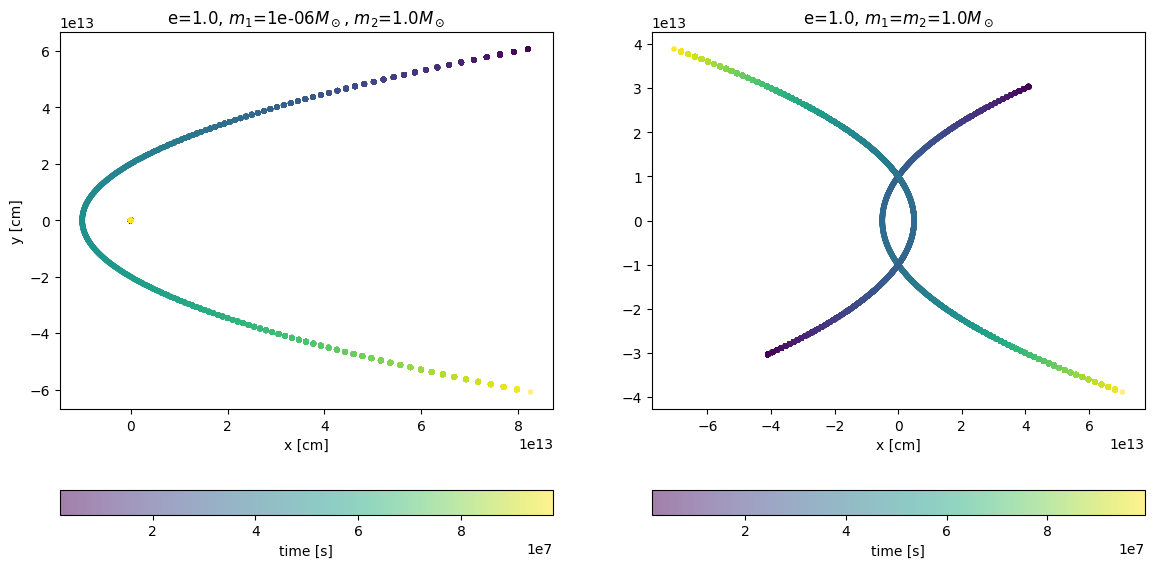

In [310]:
color_DM = t_int_to_s(times_DM)
color_SM = t_int_to_s(times_SM)

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(r_int_to_cm(M1_DM['x']),r_int_to_cm(M1_DM['y']), c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(r_int_to_cm(M2_DM['x']),r_int_to_cm(M2_DM['y']), c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(r_int_to_cm(M1_SM['x']),r_int_to_cm(M1_SM['y']), c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(r_int_to_cm(M2_SM['x']),r_int_to_cm(M2_SM['y']), c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [s]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [s]')
axs[0].set_xlabel('x [cm]')
axs[0].set_ylabel('y [cm]')
axs[1].set_xlabel('x [cm]')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

In [311]:
def r(x1, y1, x2, y2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

In [312]:
x1 = np.array(M1_DM['x'])
x2 = np.array(M2_DM['x'])
y1 = np.array(M1_DM['y'])
y2 = np.array(M2_DM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_DM.iloc[0]['m'] + M2_DM.iloc[0]['m']
mu = (M1_DM.iloc[0]['m'] * M2_DM.iloc[0]['m'])/M

rad_DM = r(x1, y1, x2, y2)
vrad_DM = r(np.array(M1_DM['vx']),np.array(M1_DM['vy']),np.array(M2_DM['vx']),np.array(M2_DM['vy']))

EG_DM = -M*mu/rad_DM
EK_DM = 0.5*mu*vrad_DM**2

print("DIFFERENT MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_DM =',e, "to be compared with", e_DM)

a_s = (aper+aapo)/2
print('a_DM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_DM+m2_DM)/(2*a)
print('E_tot,DM =',Etot, "to be compared with", E)

print(" ")

x1 = np.array(M1_SM['x'])
x2 = np.array(M2_SM['x'])
y1 = np.array(M1_SM['y'])
y2 = np.array(M2_SM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_SM.iloc[0]['m'] + M2_SM.iloc[0]['m']
mu = (M1_SM.iloc[0]['m'] * M2_SM.iloc[0]['m'])/M

print("SAME MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_SM =',e, "to be compared with", e_SM)

a_s = (aper+aapo)/2
print('a_SM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_SM+m2_SM)/(2*a)
print('E_tot,SM =',Etot, "to be compared with", E)

rad_SM = r(x1, y1, x2, y2)
vrad_SM = r(np.array(M1_SM['vx']),np.array(M1_SM['vy']),np.array(M2_SM['vx']),np.array(M2_SM['vy']))

EG_SM = -M*mu/rad_SM
EK_SM = 0.5*mu*vrad_SM**2

DIFFERENT MASS
e_DM = 0.8222513506466176 to be compared with 1.0
a_DM = 11.009703065417916 to be compared with 2.935420743639922
E_tot,DM = -0.045414530894164536 to be compared with -0.17033350366666664
 
SAME MASS
e_SM = 0.8830092890455586 to be compared with 1.0
a_SM = 16.727480615293583 to be compared with 2.935420743639922
E_tot,SM = -0.05978186572135203 to be compared with -0.3406666666666667


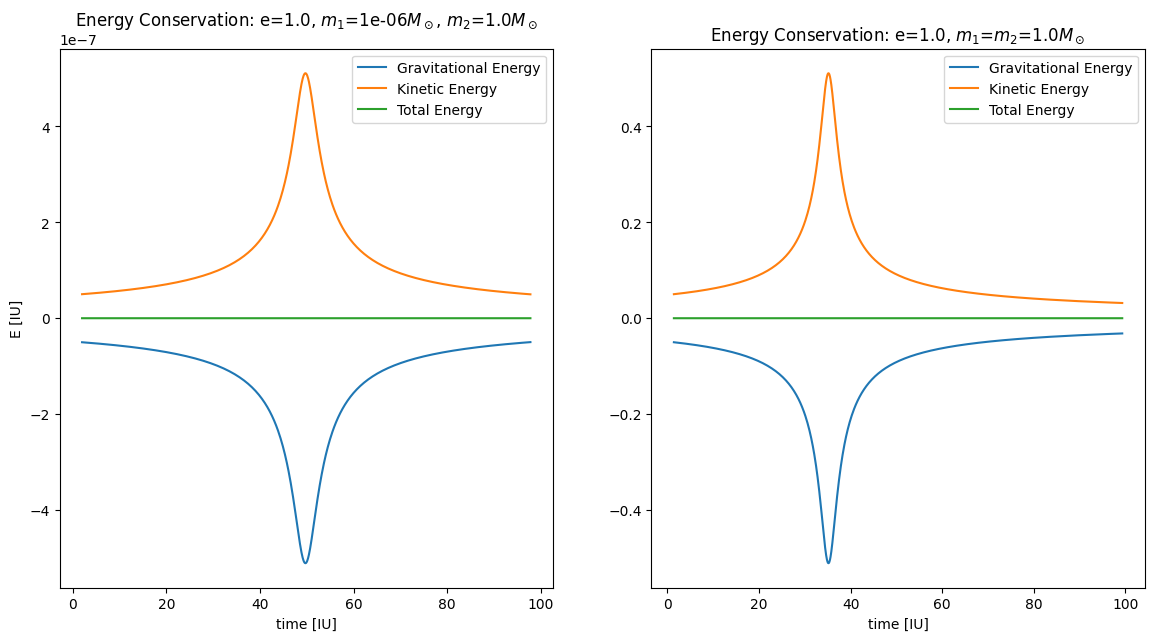

In [313]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,EG_DM,label='Gravitational Energy')
axs[0].plot(times_DM,EK_DM,label='Kinetic Energy')
axs[0].plot(times_DM,EK_DM+EG_DM,label='Total Energy')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('E [IU]')
axs[0].set_title('Energy Conservation:'+' e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[0].legend()

axs[1].plot(times_SM,EG_SM,label='Gravitational Energy')
axs[1].plot(times_SM,EK_SM,label='Kinetic Energy')
axs[1].plot(times_SM,EK_SM+EG_SM,label='Total Energy')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Energy Conservation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()

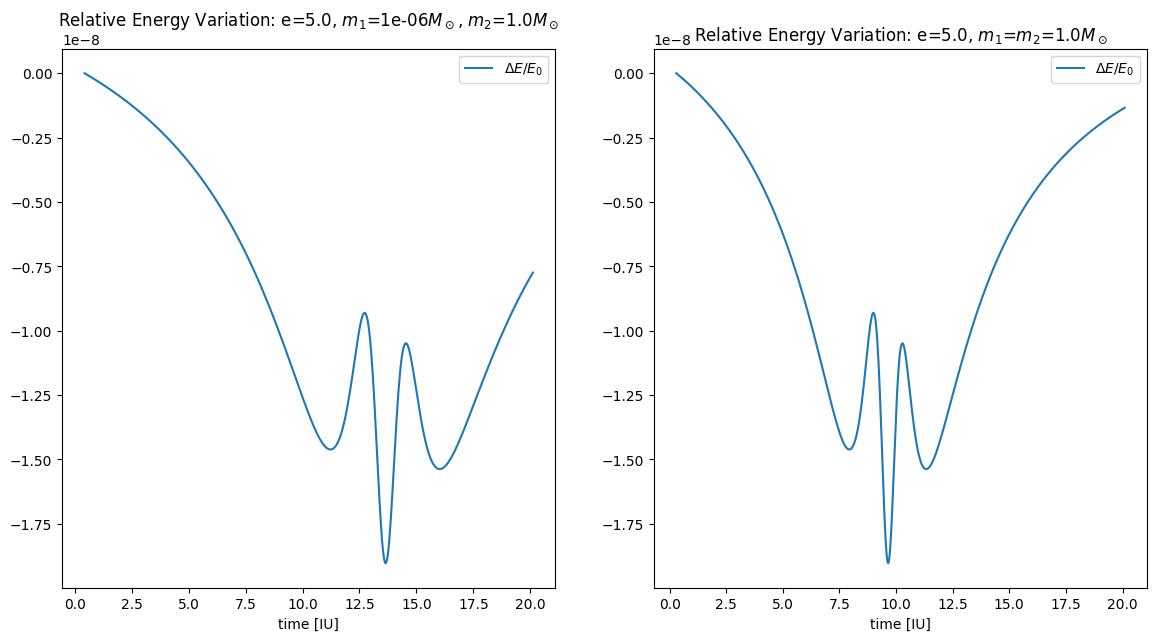

In [330]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,(EK_DM+EG_DM-(EK_DM[0]+EG_DM[0]))/(EK_DM[0]+EG_DM[0]),label=r'$\Delta E/E_0$')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('')
axs[0].set_title('Relative Energy Variation:'+' e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[0].legend()

axs[1].plot(times_SM,(EK_SM+EG_SM-(EK_SM[0]+EG_SM[0]))/(EK_SM[0]+EG_SM[0]),label=r'$\Delta E/E_0$')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Relative Energy Variation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()

## HYPERBOLE: PARAMETERS

### Different Mass

In [315]:
m1_DM = 1.0e-6
m2_DM = 1.0

e_DM = 5.0

rp_cm = 1.0e13
rp = cm_to_u(rp_cm)

start_factor = 10.5

# orientazione nel piano
omega_deg = 0.0

ic = two_body_ic_hyperbolic_from_rp(
    m1=m1_DM,
    m2=m2_DM,
    rp=rp,
    e=e_DM,
    start_factor=start_factor,
    omega_deg=omega_deg,
    G=1.0
)

print_ic_summary(ic)

write_ic_file("IC_hyper_DM.txt", ic, t0=0.0)
print("\nFile IC_hyper.txt scritto correttamente.")

===== PARAMETERS =====
m1        = 1e-06
m2        = 1.0
M         = 1.000001
e         = 5.0
rp        = 1.9569471624266144
p         = 11.741682974559687
r0        = 20.54794520547945

===== ANGLES =====
phi0 [rad]    = -1.6566159173007924
theta0 [rad] = -1.6566159173007924

===== RELATIVE MOTION =====
r_rel = [ -1.76125245 -20.47232381   0.        ]
v_rel = [0.29075941 1.43415286 0.        ]
vr0   = -1.453797070793451
vt0   = 0.16676196094747622

===== DYNAMICAL CHECKS =====
h         = 3.4266156359070457
eps       = 1.022001022   (deve essere > 0)
a         = -0.4892367906066536     (deve essere < 0)
vinf      = 1.4296859948953826
b         = 2.3967610007663174
rp_check  = 1.9569471624266124

===== BODY 1 =====
r1 = [ 1.76125068 20.47230333 -0.        ]
v1 = [-0.29075912 -1.43415143 -0.        ]

===== BODY 2 =====
r2 = [-1.76125068e-06 -2.04723033e-05  0.00000000e+00]
v2 = [2.90759123e-07 1.43415143e-06 0.00000000e+00]

File IC_hyper.txt scritto correttamente.


### Same Mass

In [316]:
m1_SM = 1.0
m2_SM = 1.0

e_SM = 5.0

rp_cm = 1.0e13
rp = cm_to_u(rp_cm)

start_factor = 10.5

# orientazione nel piano
omega_deg = 0.0

ic = two_body_ic_hyperbolic_from_rp(
    m1=m1_SM,
    m2=m2_SM,
    rp=rp,
    e=e_SM,
    start_factor=start_factor,
    omega_deg=omega_deg,
    G=1.0
)

print_ic_summary(ic)

write_ic_file("IC_hyper_SM.txt", ic, t0=0.0)
print("\nFile IC_hyper.txt scritto correttamente.")

===== PARAMETERS =====
m1        = 1.0
m2        = 1.0
M         = 2.0
e         = 5.0
rp        = 1.9569471624266144
p         = 11.741682974559687
r0        = 20.54794520547945

===== ANGLES =====
phi0 [rad]    = -1.6566159173007924
theta0 [rad] = -1.6566159173007924

===== RELATIVE MOTION =====
r_rel = [ -1.76125245 -20.47232381   0.        ]
v_rel = [0.4111957  2.02819742 0.        ]
vr0   = -2.0559785064653813
vt0   = 0.2358369089414283

===== DYNAMICAL CHECKS =====
h         = 4.845963882358117
eps       = 2.044000000000001   (deve essere > 0)
a         = -0.48923679060665337     (deve essere < 0)
vinf      = 2.0218803129760183
b         = 2.3967610007663174
rp_check  = 1.9569471624266124

===== BODY 1 =====
r1 = [ 0.88062622 10.2361619  -0.        ]
v1 = [-0.20559785 -1.01409871 -0.        ]

===== BODY 2 =====
r2 = [ -0.88062622 -10.2361619    0.        ]
v2 = [0.20559785 1.01409871 0.        ]

File IC_hyper.txt scritto correttamente.


In [317]:
theta = np.linspace(0,np.pi*2*5,1000)
x1_DM,y1_DM,x2_DM,y2_DM=analytical(theta,0,a,e_DM,m1_DM,m2_DM)
x1_SM,y1_SM,x2_SM,y2_SM=analytical(theta,0,a,e_SM,m1_SM,m2_SM)

In [318]:
data_DM = pd.read_csv('2b_output_hyper_DM.txt', sep=' ', header=None, names=range(7))
data_DM.columns = ['m','x','y','z','vx','vy','vz']

data_SM = pd.read_csv('2b_output_hyper_SM.txt', sep=' ', header=None, names=range(7))
data_SM.columns = ['m','x','y','z','vx','vy','vz']

In [319]:
#print(data_DM, data_SM)

In [320]:
times_DM, M1_DM, M2_DM = rows(data_DM)
times_SM, M1_SM, M2_SM = rows(data_SM)

Text(0.5, 1.0, 'e=5.0, $m_1$=$m_2$=1.0$M_\\odot$')

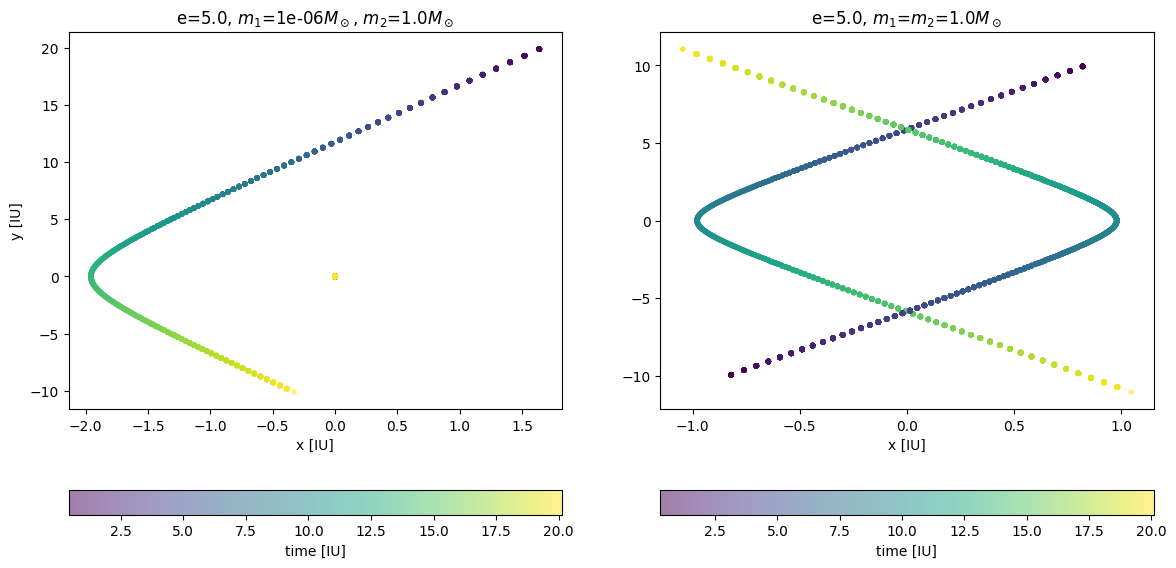

In [321]:
color_DM = times_DM
color_SM = times_SM

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(M1_DM['x'],M1_DM['y'], c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(M2_DM['x'],M2_DM['y'], c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(M1_SM['x'],M1_SM['y'], c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(M2_SM['x'],M2_SM['y'], c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [IU]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [IU]')
axs[0].set_xlabel('x [IU]')
axs[0].set_ylabel('y [IU]')
axs[1].set_xlabel('x [IU]')

#axs[0].plot(x1_DM,y1_DM, lw=0.5, c='crimson')
#axs[0].plot(x2_DM,y2_DM, lw=0.5, c='crimson')
#axs[1].plot(x1_SM,y1_SM, lw=0.5, c='crimson')
#axs[1].plot(x2_SM,y2_SM, lw=0.5, c='crimson')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

Text(0.5, 1.0, 'e=5.0, $m_1$=$m_2$=1.0$M_\\odot$')

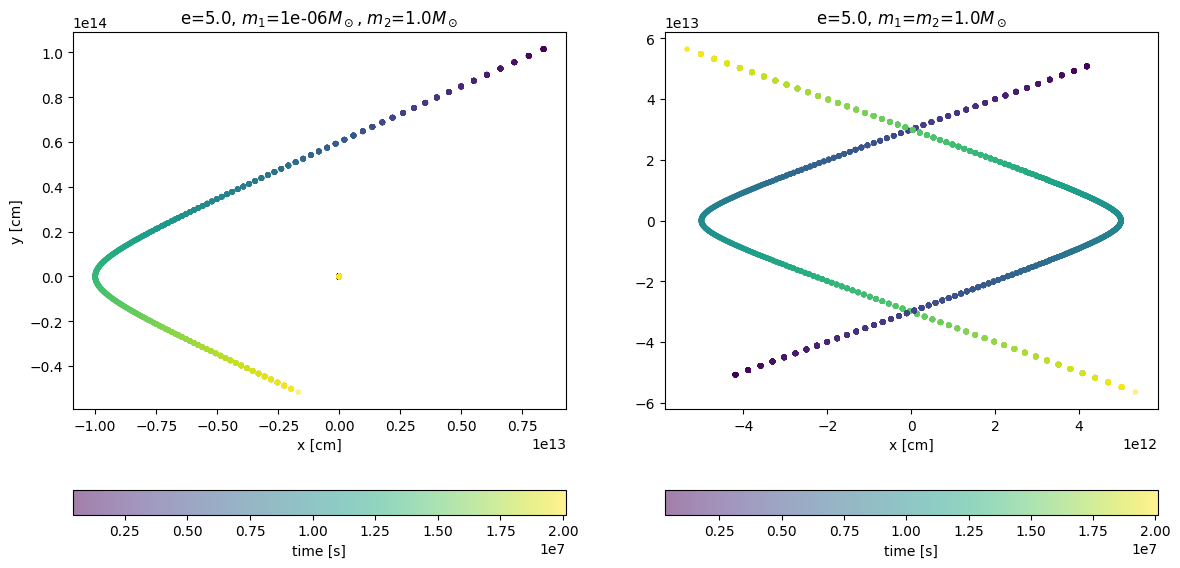

In [322]:
color_DM = t_int_to_s(times_DM)
color_SM = t_int_to_s(times_SM)

fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

DM_orbit=axs[0].scatter(r_int_to_cm(M1_DM['x']),r_int_to_cm(M1_DM['y']), c=color_DM,  marker='.', alpha=0.5)
axs[0].scatter(r_int_to_cm(M2_DM['x']),r_int_to_cm(M2_DM['y']), c=color_DM, marker='.', alpha=1)

DS_orbit=axs[1].scatter(r_int_to_cm(M1_SM['x']),r_int_to_cm(M1_SM['y']), c=color_SM,  marker='.', alpha=0.5)
axs[1].scatter(r_int_to_cm(M2_SM['x']),r_int_to_cm(M2_SM['y']), c=color_SM, marker='.', alpha=1)

fig.colorbar(DM_orbit,orientation='horizontal',label='time [s]')
fig.colorbar(DS_orbit,orientation='horizontal',label='time [s]')
axs[0].set_xlabel('x [cm]')
axs[0].set_ylabel('y [cm]')
axs[1].set_xlabel('x [cm]')

axs[0].set_title('e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[1].set_title('e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')

In [323]:
def r(x1, y1, x2, y2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

In [324]:
x1 = np.array(M1_DM['x'])
x2 = np.array(M2_DM['x'])
y1 = np.array(M1_DM['y'])
y2 = np.array(M2_DM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_DM.iloc[0]['m'] + M2_DM.iloc[0]['m']
mu = (M1_DM.iloc[0]['m'] * M2_DM.iloc[0]['m'])/M

rad_DM = r(x1, y1, x2, y2)
vrad_DM = r(np.array(M1_DM['vx']),np.array(M1_DM['vy']),np.array(M2_DM['vx']),np.array(M2_DM['vy']))

EG_DM = -M*mu/rad_DM
EK_DM = 0.5*mu*vrad_DM**2

print("DIFFERENT MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_DM =',e, "to be compared with", e_DM)

a_s = (aper+aapo)/2
print('a_DM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_DM+m2_DM)/(2*a)
print('E_tot,DM =',Etot, "to be compared with", E)

print(" ")

x1 = np.array(M1_SM['x'])
x2 = np.array(M2_SM['x'])
y1 = np.array(M1_SM['y'])
y2 = np.array(M2_SM['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

M = M1_SM.iloc[0]['m'] + M2_SM.iloc[0]['m']
mu = (M1_SM.iloc[0]['m'] * M2_SM.iloc[0]['m'])/M

print("SAME MASS")

e = (-aper+aapo)/(aper+aapo)
print('e_SM =',e, "to be compared with", e_SM)

a_s = (aper+aapo)/2
print('a_SM =',a_s, "to be compared with", a)

Etot = -M/(2*a_s)
E=-(m1_SM+m2_SM)/(2*a)
print('E_tot,SM =',Etot, "to be compared with", E)

rad_SM = r(x1, y1, x2, y2)
vrad_SM = r(np.array(M1_SM['vx']),np.array(M1_SM['vy']),np.array(M2_SM['vx']),np.array(M2_SM['vy']))

EG_SM = -M*mu/rad_SM
EK_SM = 0.5*mu*vrad_SM**2

DIFFERENT MASS
e_DM = 0.8212207681435015 to be compared with 5.0
a_DM = 10.946191960901166 to be compared with 2.935420743639922
E_tot,DM = -0.04567803139082137 to be compared with -0.17033350366666664
 
SAME MASS
e_SM = 0.8379532022039459 to be compared with 5.0
a_SM = 12.076460733192873 to be compared with 2.935420743639922
E_tot,SM = -0.08280571784177133 to be compared with -0.3406666666666667


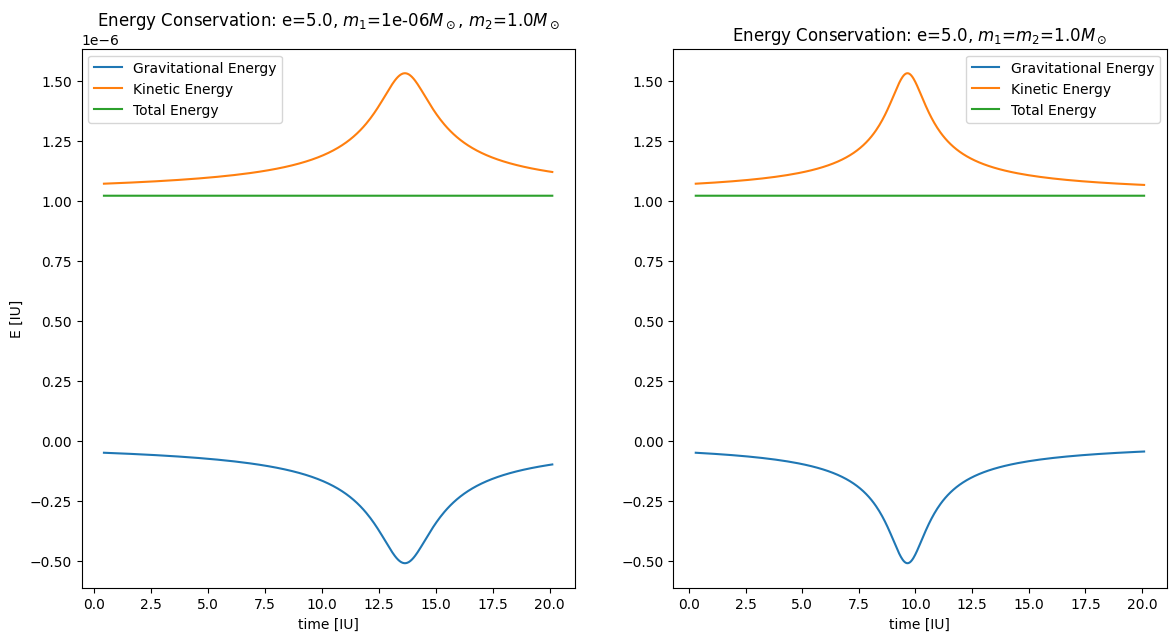

In [325]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,EG_DM,label='Gravitational Energy')
axs[0].plot(times_DM,EK_DM,label='Kinetic Energy')
axs[0].plot(times_DM,EK_DM+EG_DM,label='Total Energy')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('E [IU]')
axs[0].set_title('Energy Conservation:'+' e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[0].legend()

axs[1].plot(times_SM,EG_SM,label='Gravitational Energy')
axs[1].plot(times_SM,EK_SM,label='Kinetic Energy')
axs[1].plot(times_SM,EK_SM+EG_SM,label='Total Energy')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Energy Conservation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()

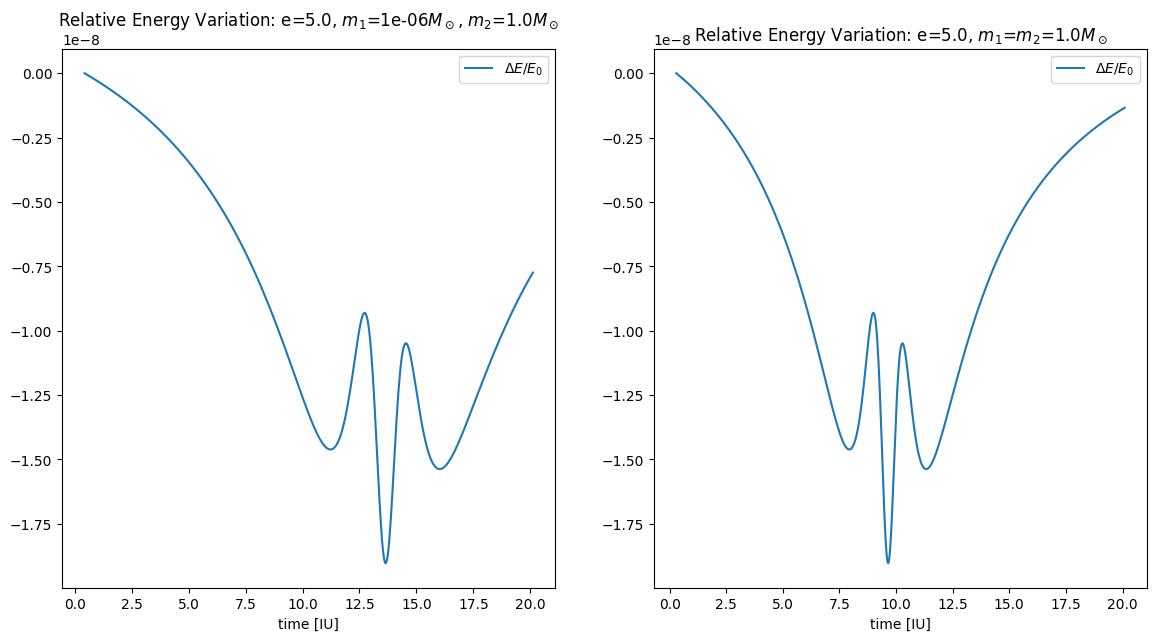

In [329]:
fig = plt.figure(figsize=(14, 7))
axs = fig.subplots(1, 2)

axs[0].plot(times_DM,(EK_DM+EG_DM-(EK_DM[0]+EG_DM[0]))/(EK_DM[0]+EG_DM[0]),label=r'$\Delta E/E_0$')
axs[0].set_xlabel('time [IU]')
axs[0].set_ylabel('')
axs[0].set_title('Relative Energy Variation:'+' e='+str(e_DM)+r', $m_1$='+str(m1_DM)+r'$M_\odot$, $m_2$='+str(m2_DM)+r'$M_\odot$')
axs[0].legend()

axs[1].plot(times_SM,(EK_SM+EG_SM-(EK_SM[0]+EG_SM[0]))/(EK_SM[0]+EG_SM[0]),label=r'$\Delta E/E_0$')
axs[1].set_xlabel('time [IU]')
axs[1].set_title('Relative Energy Variation:'+' e='+str(e_SM)+r', $m_1$=$m_2$='+str(m1_SM)+r'$M_\odot$')
axs[1].legend()